<a href="https://colab.research.google.com/github/Nadaramadan1/Assignment-Week-1/blob/main/coding%20task%202.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
# Task: Apply and Compare Multiple Convolution Filters
import cv2
import numpy as np
import matplotlib.pyplot as plt


In [19]:
# Load and convert to grayscale
img = cv2.imread('/content/kalen-emsley-Bkci_8qcdvQ-unsplash.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

In [20]:
# --- Define kernels --
# 1. Box blur (averaging)
kernel_blur = np.ones((5, 5), np.float32) / 25
# 2. Gaussian blur (built-in)
# (done via cv2.GaussianBlur)
# 3. Sobel edge detection (X direction)
kernel_sobel_x = np.array([[-1, 0, 1],
                          [-2, 0, 2],
                          [-1, 0, 1]], dtype=np.float32)
# 4. Laplacian edge detection
kernel_laplacian = np.array([[0,  1, 0],
                             [1, -4, 1],
                             [0,  1, 0]], dtype=np.float32)
# 5. Sharpening
kernel_sharpen = np.array([[ 0, -1,  0],
                           [-1,  5, -1],
                           [ 0, -1,  0]], dtype=np.float32)

In [21]:
# --- Apply filters --
blurred    = cv2.filter2D(gray, -1, kernel_blur)
gaussian   = cv2.GaussianBlur(gray, (5, 5), 0)
edge_x     = cv2.filter2D(gray, -1, kernel_sobel_x)
laplacian  = cv2.filter2D(gray, -1, kernel_laplacian)
sharpened  = cv2.filter2D(gray, -1, kernel_sharpen)

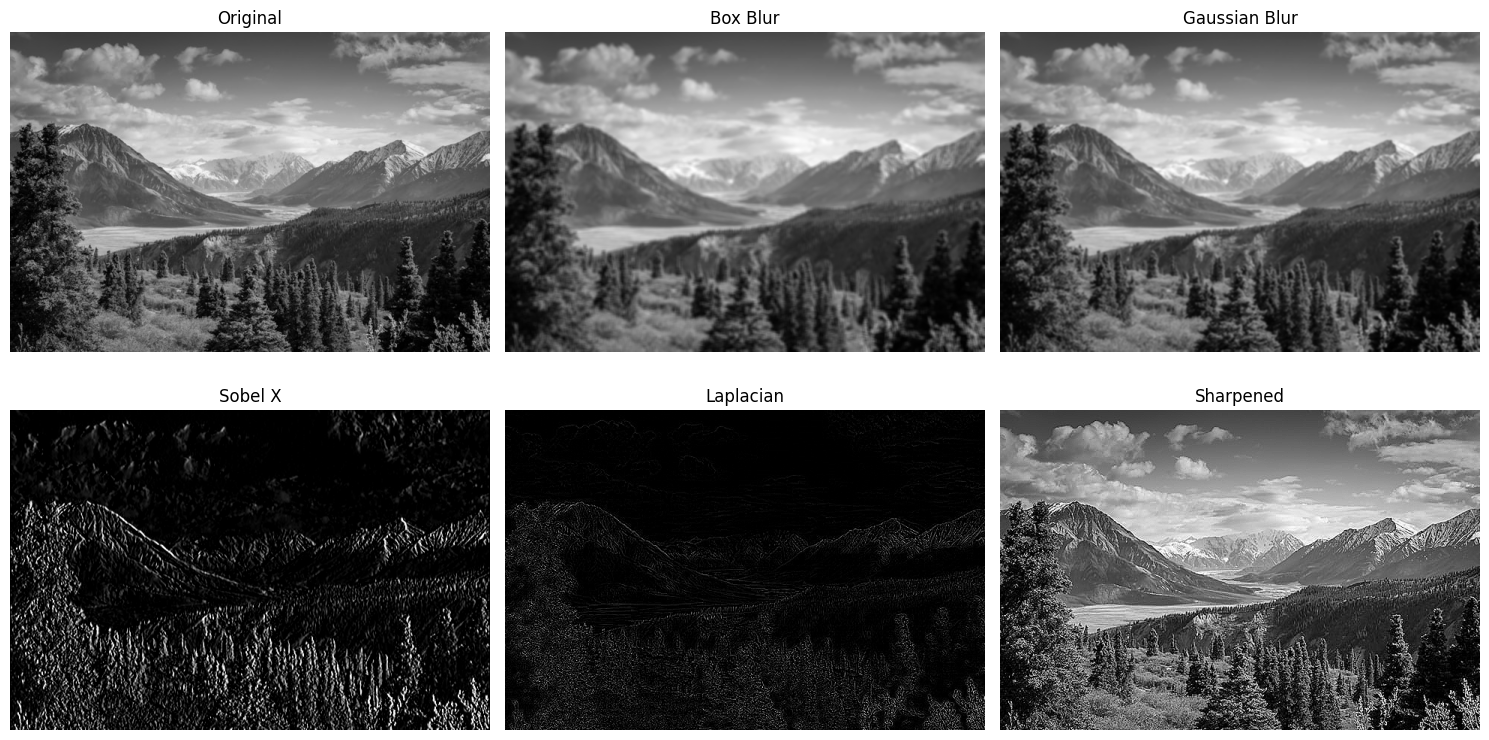

In [22]:
# --- Display all results --
titles  = ['Original', 'Box Blur', 'Gaussian Blur', 'Sobel X', 'Laplacian', 'Sharpened']
images  = [
    gray,
    blurred,
    gaussian,
    np.abs(edge_x).astype(np.uint8),
    np.abs(laplacian).astype(np.uint8),
    sharpened
]
plt.figure(figsize=(15, 8))
for i, (t, im) in enumerate(zip(titles, images)):
    plt.subplot(2, 3, i+1)
    plt.imshow(im, cmap='gray')
    plt.title(t)
    plt.axis('off')
plt.tight_layout()
plt.show()